# Etapa 11 — Análise e gráficos

Notebook principal para análise dos resultados experimentais do TCC.

Objetivo: carregar o dataset normalizado, validar colunas obrigatórias, separar `workflow_total` das etapas operacionais e preparar estatísticas e gráficos acadêmicos.

## 1. Importação das bibliotecas e configuração dos caminhos

Nesta seção, importamos as bibliotecas necessárias e definimos os caminhos do dataset consolidado e da pasta onde os gráficos serão salvos.

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = None

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'analysis' / 'processed' / 'results_normalized.csv').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar analysis/processed/results_normalized.csv')

DATA_PATH = PROJECT_ROOT / 'analysis' / 'processed' / 'results_normalized.csv'
CHARTS_DIR = PROJECT_ROOT / 'analysis' / 'charts'

CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print('Raiz do projeto:', PROJECT_ROOT)
print('CSV encontrado:', DATA_PATH.exists())
print('Pasta de gráficos:', CHARTS_DIR)

Raiz do projeto: c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline
CSV encontrado: True
Pasta de gráficos: c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\charts


## 2. Carregamento e validação inicial do dataset

Nesta seção, carregamos o arquivo `results_normalized.csv` e verificamos se ele contém as colunas obrigatórias para a análise experimental.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dimensões do dataset:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\nColunas encontradas:")
print(df.columns.tolist())

df.head()

Dimensões do dataset:
Linhas: 235
Colunas: 19

Colunas encontradas:
['scenario_key', 'scenario_order', 'scenario_label', 'security_layer', 'run_index', 'source_file', 'scenario', 'run_id', 'run_number', 'commit_sha', 'step_name', 'start_timestamp', 'end_timestamp', 'duration_seconds', 'status', 'is_workflow_total', 'is_security_step', 'is_deploy_step', 'is_valid_execution']


,scenario_key,scenario_order,scenario_label,security_layer,run_index,source_file,scenario,run_id,run_number,commit_sha,step_name,start_timestamp,end_timestamp,duration_seconds,status,is_workflow_total,is_security_step,is_deploy_step,is_valid_execution
0,c1,1,C1 - Baseline,none,1,analysis/raw/c1/timing/c1_run_1.csv,C1-baseline,26467314674,3,51e9139b6311cd565bf7a83518f66a2daeffd33e,docker_build,5/26/26 18:29,5/26/26 18:29,13,success,False,False,False,True
1,c1,1,C1 - Baseline,none,1,analysis/raw/c1/timing/c1_run_1.csv,C1-baseline,26467314674,3,51e9139b6311cd565bf7a83518f66a2daeffd33e,install_dependencies,5/26/26 18:29,5/26/26 18:29,9,success,False,False,False,True
2,c1,1,C1 - Baseline,none,1,analysis/raw/c1/timing/c1_run_1.csv,C1-baseline,26467314674,3,51e9139b6311cd565bf7a83518f66a2daeffd33e,kubernetes_deploy,5/26/26 18:30,5/26/26 18:30,27,success,False,False,True,True
3,c1,1,C1 - Baseline,none,1,analysis/raw/c1/timing/c1_run_1.csv,C1-baseline,26467314674,3,51e9139b6311cd565bf7a83518f66a2daeffd33e,kubernetes_smoke_test,5/26/26 18:30,5/26/26 18:30,5,success,False,False,True,True
4,c1,1,C1 - Baseline,none,1,analysis/raw/c1/timing/c1_run_1.csv,C1-baseline,26467314674,3,51e9139b6311cd565bf7a83518f66a2daeffd33e,unit_tests,5/26/26 18:29,5/26/26 18:29,2,success,False,False,False,True


In [3]:
required_columns = [
    "scenario",
    "run_id",
    "run_number",
    "commit_sha",
    "step_name",
    "start_timestamp",
    "end_timestamp",
    "duration_seconds",
    "status",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing_columns}")

print("Todas as colunas obrigatórias foram encontradas.")

Todas as colunas obrigatórias foram encontradas.


In [4]:
print("Tipos de dados:")
print(df.dtypes)

print("\nQuantidade de registros por status:")
print(df["status"].value_counts(dropna=False))

print("\nCenários encontrados:")
print(df["scenario"].value_counts().sort_index())

print("\nEtapas encontradas:")
print(df["step_name"].value_counts().sort_index())

Tipos de dados:
scenario_key            str
scenario_order        int64
scenario_label          str
security_layer          str
run_index             int64
source_file             str
scenario                str
run_id                int64
run_number            int64
commit_sha              str
step_name               str
start_timestamp         str
end_timestamp           str
duration_seconds      int64
status                  str
is_workflow_total      bool
is_security_step       bool
is_deploy_step         bool
is_valid_execution     bool
dtype: object

Quantidade de registros por status:
status
success    235
Name: count, dtype: int64

Cenários encontrados:
scenario
C1-baseline         30
C2-sast             35
C3-sast-sca         50
C4-sast-sca-dast    60
C5-optimized        60
Name: count, dtype: int64

Etapas encontradas:
step_name
dast_health_check        10
dast_zap_baseline        10
docker_build             25
install_dependencies     25
kubernetes_deploy        25
kubernete

## 3. Filtragem das execuções válidas

Nesta seção, mantemos apenas registros marcados como execuções válidas. Isso evita misturar medições de execuções incompletas, falhas ou inválidas na análise estatística.

In [5]:
valid_df = df[df["is_valid_execution"] == True].copy()

print("Registros totais:", len(df))
print("Registros válidos:", len(valid_df))

print("\nStatus nas execuções válidas:")
print(valid_df["status"].value_counts(dropna=False))

Registros totais: 235
Registros válidos: 235

Status nas execuções válidas:
status
success    235
Name: count, dtype: int64


## 4. Separação da métrica principal de lead time

A métrica `workflow_total` representa o tempo total do workflow CI/CD. Ela será usada como principal métrica de lead time.

> [!IMPORTANT]
> `workflow_total` não deve ser tratado como etapa operacional, pois ele representa o tempo total agregado da execução.

In [6]:
workflow_df = valid_df[valid_df["step_name"] == "workflow_total"].copy()

print("Registros de workflow_total:", len(workflow_df))

print("\nQuantidade de workflow_total por cenário:")
print(
    workflow_df
    .groupby(["scenario_order", "scenario_label"])
    .size()
    .reset_index(name="runs")
    .sort_values("scenario_order")
)

Registros de workflow_total: 25

Quantidade de workflow_total por cenário:
   scenario_order          scenario_label  runs
0               1           C1 - Baseline     5
1               2               C2 - SAST     5
2               3         C3 - SAST + SCA     5
3               4  C4 - SAST + SCA + DAST     5
4               5          C5 - Optimized     5


## 5. Estatísticas descritivas do lead time por cenário

Nesta seção, calculamos as estatísticas descritivas usando apenas `workflow_total`, pois essa é a métrica principal de lead time do pipeline.

In [7]:
scenario_stats = (
    workflow_df
    .groupby(["scenario_order", "scenario_key", "scenario_label"])
    .agg(
        executions=("duration_seconds", "count"),
        mean_seconds=("duration_seconds", "mean"),
        median_seconds=("duration_seconds", "median"),
        min_seconds=("duration_seconds", "min"),
        max_seconds=("duration_seconds", "max"),
        std_seconds=("duration_seconds", "std"),
    )
    .reset_index()
    .sort_values("scenario_order")
)

scenario_stats_rounded = scenario_stats.copy()

numeric_columns = [
    "mean_seconds",
    "median_seconds",
    "min_seconds",
    "max_seconds",
    "std_seconds",
]

scenario_stats_rounded[numeric_columns] = scenario_stats_rounded[numeric_columns].round(2)

scenario_stats_rounded

,scenario_order,scenario_key,scenario_label,executions,mean_seconds,median_seconds,min_seconds,max_seconds,std_seconds
0,1,c1,C1 - Baseline,5,87.0,87.0,80,93,5.61
1,2,c2,C2 - SAST,5,90.4,88.0,79,108,10.69
2,3,c3,C3 - SAST + SCA,5,126.2,127.0,107,149,16.02
3,4,c4,C4 - SAST + SCA + DAST,5,236.6,207.0,197,309,49.67
4,5,c5,C5 - Optimized,5,191.8,180.0,172,240,27.63


## 6. Overhead incremental entre cenários

Nesta seção, calculamos o impacto incremental de cada novo cenário em relação ao cenário anterior.

A comparação segue a lógica experimental:

- C2 contra C1: impacto do SAST;
- C3 contra C2: impacto do SCA;
- C4 contra C3: impacto do DAST;
- C5 contra C4: impacto das otimizações.

In [8]:
scenario_means = (
    scenario_stats
    .set_index("scenario_key")["mean_seconds"]
    .to_dict()
)

incremental_comparisons = [
    {
        "comparison": "C2 - C1",
        "interpretation": "Impacto do SAST",
        "reference": "c1",
        "target": "c2",
    },
    {
        "comparison": "C3 - C2",
        "interpretation": "Impacto do SCA",
        "reference": "c2",
        "target": "c3",
    },
    {
        "comparison": "C4 - C3",
        "interpretation": "Impacto do DAST",
        "reference": "c3",
        "target": "c4",
    },
    {
        "comparison": "C5 - C4",
        "interpretation": "Impacto das otimizações",
        "reference": "c4",
        "target": "c5",
    },
]

incremental_overhead = []

for item in incremental_comparisons:
    reference_mean = scenario_means[item["reference"]]
    target_mean = scenario_means[item["target"]]
    
    absolute_overhead = target_mean - reference_mean
    percentage_overhead = (absolute_overhead / reference_mean) * 100
    
    incremental_overhead.append({
        "comparison": item["comparison"],
        "interpretation": item["interpretation"],
        "reference_mean_seconds": reference_mean,
        "target_mean_seconds": target_mean,
        "absolute_overhead_seconds": absolute_overhead,
        "percentage_overhead": percentage_overhead,
    })

incremental_overhead_df = pd.DataFrame(incremental_overhead)

incremental_overhead_df[
    [
        "reference_mean_seconds",
        "target_mean_seconds",
        "absolute_overhead_seconds",
        "percentage_overhead",
    ]
] = incremental_overhead_df[
    [
        "reference_mean_seconds",
        "target_mean_seconds",
        "absolute_overhead_seconds",
        "percentage_overhead",
    ]
].round(2)

incremental_overhead_df

,comparison,interpretation,reference_mean_seconds,target_mean_seconds,absolute_overhead_seconds,percentage_overhead
0,C2 - C1,Impacto do SAST,87.0,90.4,3.4,3.91
1,C3 - C2,Impacto do SCA,90.4,126.2,35.8,39.60
2,C4 - C3,Impacto do DAST,126.2,236.6,110.4,87.48
3,C5 - C4,Impacto das otimizações,236.6,191.8,-44.8,-18.93


## 7. Overhead percentual em relação ao baseline

Nesta seção, calculamos quanto cada cenário aumentou ou reduziu o tempo médio em comparação com o C1, que representa o pipeline baseline sem ferramentas de segurança.

In [9]:
baseline_mean = scenario_means["c1"]

baseline_overhead = scenario_stats.copy()

baseline_overhead["absolute_overhead_vs_c1_seconds"] = (
    baseline_overhead["mean_seconds"] - baseline_mean
)

baseline_overhead["percentage_overhead_vs_c1"] = (
    baseline_overhead["absolute_overhead_vs_c1_seconds"] / baseline_mean
) * 100

baseline_overhead_rounded = baseline_overhead[
    [
        "scenario_order",
        "scenario_key",
        "scenario_label",
        "mean_seconds",
        "absolute_overhead_vs_c1_seconds",
        "percentage_overhead_vs_c1",
    ]
].copy()

baseline_overhead_rounded[
    [
        "mean_seconds",
        "absolute_overhead_vs_c1_seconds",
        "percentage_overhead_vs_c1",
    ]
] = baseline_overhead_rounded[
    [
        "mean_seconds",
        "absolute_overhead_vs_c1_seconds",
        "percentage_overhead_vs_c1",
    ]
].round(2)

baseline_overhead_rounded

,scenario_order,scenario_key,scenario_label,mean_seconds,absolute_overhead_vs_c1_seconds,percentage_overhead_vs_c1
0,1,c1,C1 - Baseline,87.0,0.0,0.00
1,2,c2,C2 - SAST,90.4,3.4,3.91
2,3,c3,C3 - SAST + SCA,126.2,39.2,45.06
3,4,c4,C4 - SAST + SCA + DAST,236.6,149.6,171.95
4,5,c5,C5 - Optimized,191.8,104.8,120.46


## 8. Estatísticas por etapa do pipeline

Nesta seção, analisamos o tempo médio das etapas individuais do pipeline.

> [!IMPORTANT]
> a métrica `workflow_total` será excluída desta análise, pois ela representa o tempo total do workflow, e não uma etapa operacional individual.

In [10]:
steps_df = valid_df[valid_df["step_name"] != "workflow_total"].copy()

print("Registros válidos totais:", len(valid_df))
print("Registros de etapas operacionais:", len(steps_df))

print("\nVerificação se workflow_total foi excluído:")
print(steps_df["step_name"].eq("workflow_total").sum())

Registros válidos totais: 235
Registros de etapas operacionais: 210

Verificação se workflow_total foi excluído:
0


In [11]:
stage_stats = (
    steps_df
    .groupby(["scenario_order", "scenario_label", "step_name"])
    .agg(
        executions=("duration_seconds", "count"),
        mean_seconds=("duration_seconds", "mean"),
        median_seconds=("duration_seconds", "median"),
        min_seconds=("duration_seconds", "min"),
        max_seconds=("duration_seconds", "max"),
        std_seconds=("duration_seconds", "std"),
    )
    .reset_index()
    .sort_values(["scenario_order", "mean_seconds"], ascending=[True, False])
)

stage_stats_rounded = stage_stats.copy()

stage_numeric_columns = [
    "mean_seconds",
    "median_seconds",
    "min_seconds",
    "max_seconds",
    "std_seconds",
]

stage_stats_rounded[stage_numeric_columns] = stage_stats_rounded[stage_numeric_columns].round(2)

stage_stats_rounded

,scenario_order,scenario_label,step_name,executions,mean_seconds,median_seconds,min_seconds,max_seconds,std_seconds
2,1,C1 - Baseline,kubernetes_deploy,5,27.8,28.0,27,29,0.84
0,1,C1 - Baseline,docker_build,5,14.4,13.0,12,17,2.41
1,1,C1 - Baseline,install_dependencies,5,8.2,8.0,7,9,0.84
3,1,C1 - Baseline,kubernetes_smoke_test,5,5.0,5.0,5,5,0.00
4,1,C1 - Baseline,unit_tests,5,1.6,2.0,1,2,0.55
7,2,C2 - SAST,kubernetes_deploy,5,33.4,34.0,28,37,3.29
9,2,C2 - SAST,sonarqube_sast,5,12.4,12.0,10,16,2.61
8,2,C2 - SAST,kubernetes_smoke_test,5,5.0,5.0,5,5,0.00
5,2,C2 - SAST,docker_build,5,2.2,2.0,2,3,0.45
10,2,C2 - SAST,unit_tests,5,1.0,1.0,1,1,0.00


## 9. Ranking geral das etapas mais demoradas

Nesta seção, criamos um ranking das etapas com maior tempo médio, considerando todos os cenários.

A métrica `workflow_total` continua excluída para evitar distorção, pois ela representa o tempo total do workflow.

In [12]:
stage_ranking = (
    steps_df
    .groupby("step_name")
    .agg(
        executions=("duration_seconds", "count"),
        mean_seconds=("duration_seconds", "mean"),
        median_seconds=("duration_seconds", "median"),
        min_seconds=("duration_seconds", "min"),
        max_seconds=("duration_seconds", "max"),
        std_seconds=("duration_seconds", "std"),
    )
    .reset_index()
    .sort_values("mean_seconds", ascending=False)
)

stage_ranking_rounded = stage_ranking.copy()

stage_ranking_rounded[
    [
        "mean_seconds",
        "median_seconds",
        "min_seconds",
        "max_seconds",
        "std_seconds",
    ]
] = stage_ranking_rounded[
    [
        "mean_seconds",
        "median_seconds",
        "min_seconds",
        "max_seconds",
        "std_seconds",
    ]
].round(2)

stage_ranking_rounded

,step_name,executions,mean_seconds,median_seconds,min_seconds,max_seconds,std_seconds
1,dast_zap_baseline,10,69.00,58.0,36,197,47.35
4,kubernetes_deploy,25,36.80,34.0,27,75,10.17
9,sonarqube_sast,20,18.35,15.5,10,34,7.99
2,docker_build,25,5.40,3.0,2,17,4.86
5,kubernetes_smoke_test,25,5.08,5.0,5,6,0.28
3,install_dependencies,25,2.24,1.0,0,9,3.10
10,unit_tests,25,1.40,1.0,1,3,0.58
8,sca_total,15,1.07,1.0,0,3,0.80
7,sca_image,15,0.73,0.0,0,3,0.96
6,sca_fs,15,0.13,0.0,0,1,0.35


## 10. Gráfico de lead time médio por cenário

Este gráfico mostra o tempo médio total do workflow em cada cenário experimental.

A métrica usada é `workflow_total`, pois ela representa o lead time total do pipeline CI/CD.

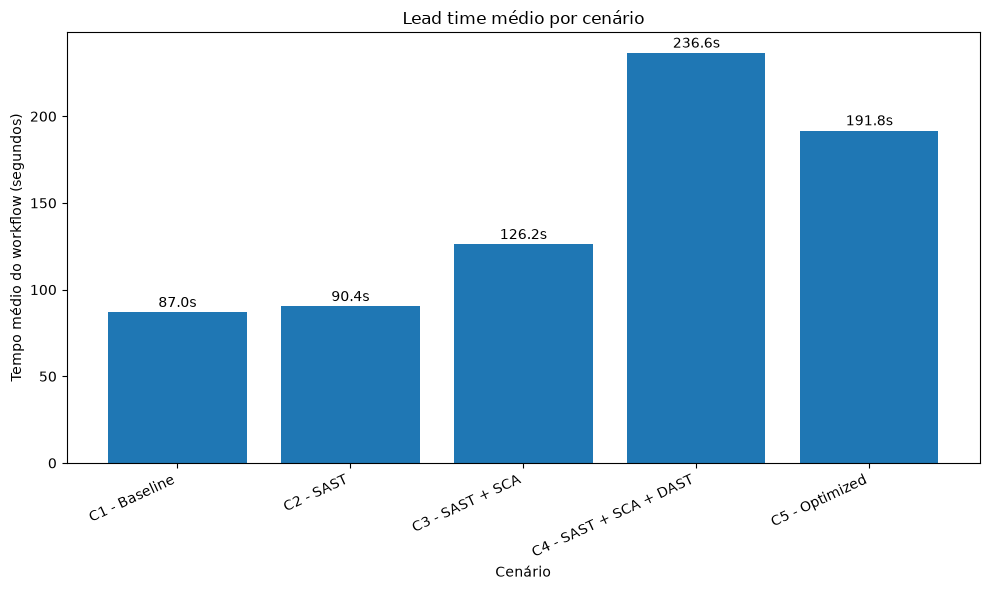

Gráfico salvo em: c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\charts\lead_time_by_scenario.png
Arquivo existe: True


In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    scenario_stats_rounded["scenario_label"],
    scenario_stats_rounded["mean_seconds"]
)

plt.title("Lead time médio por cenário")
plt.xlabel("Cenário")
plt.ylabel("Tempo médio do workflow (segundos)")
plt.xticks(rotation=25, ha="right")

for index, value in enumerate(scenario_stats_rounded["mean_seconds"]):
    plt.text(
        index,
        value + 3,
        f"{value:.1f}s",
        ha="center"
    )

plt.tight_layout()

lead_time_chart_path = CHARTS_DIR / "lead_time_by_scenario.png"
plt.savefig(lead_time_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:", lead_time_chart_path)
print("Arquivo existe:", lead_time_chart_path.exists())

## 11. Gráfico de decomposição do tempo médio por etapa

Este gráfico mostra a contribuição média de cada etapa operacional no tempo dos cenários.

A métrica `workflow_total` foi excluída, pois ela representa o tempo total do workflow e não uma etapa individual.

In [ ]:
stage_breakdown = (
    stage_stats
    .pivot_table(
        index="scenario_label",
        columns="step_name",
        values="mean_seconds",
        aggfunc="mean",
        fill_value=0
    )
)

scenario_order_labels = (
    scenario_stats
    .sort_values("scenario_order")["scenario_label"]
    .tolist()
)

stage_breakdown = stage_breakdown.reindex(scenario_order_labels)

stage_breakdown

step_name,dast_health_check,dast_zap_baseline,docker_build,install_dependencies,kubernetes_deploy,kubernetes_smoke_test,sca_fs,sca_image,sca_total,sonarqube_sast,unit_tests
scenario_label,,,,,,,,,,,
C1 - Baseline,0.0,0.0,14.4,8.2,27.8,5.0,0.0,0.0,0.0,0.0,1.6
C2 - SAST,0.0,0.0,2.2,0.8,33.4,5.0,0.0,0.0,0.0,12.4,1.0
C3 - SAST + SCA,0.0,0.0,3.4,0.6,39.0,5.0,0.0,0.4,0.6,20.4,1.8
C4 - SAST + SCA + DAST,0.0,90.0,4.4,1.2,48.4,5.2,0.2,0.2,0.8,24.8,1.2
C5 - Optimized,0.0,48.0,2.6,0.4,35.4,5.2,0.2,1.6,1.8,15.8,1.4


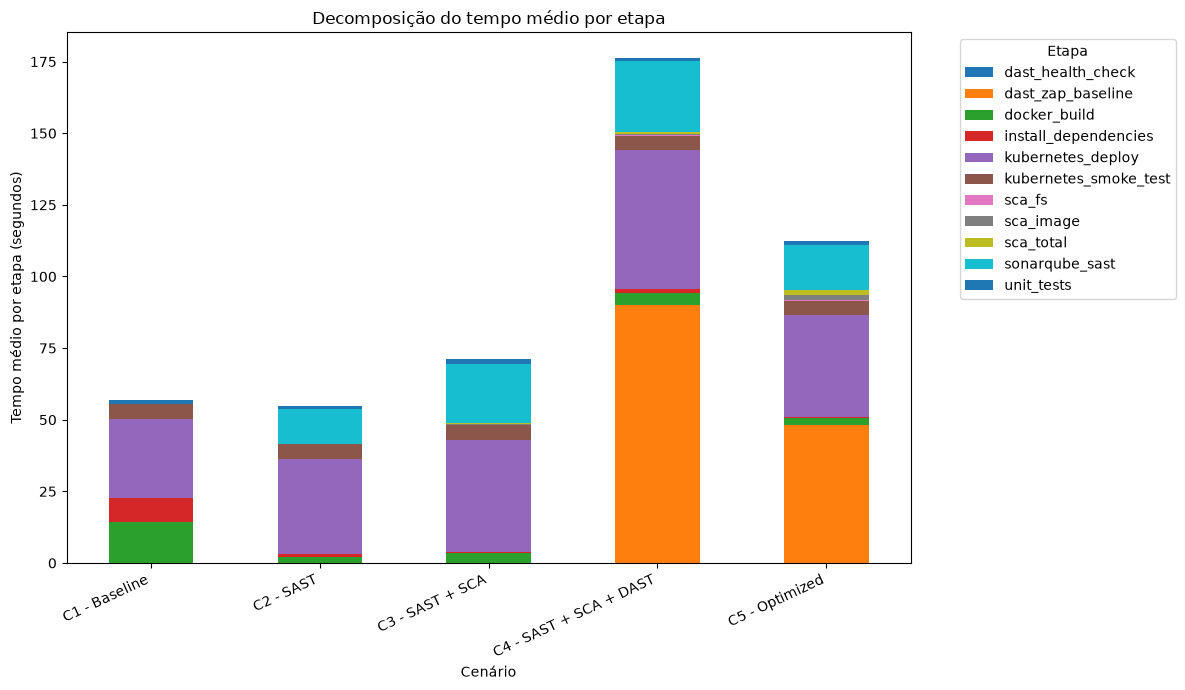

Gráfico salvo em: c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\charts\stage_time_breakdown.png
Arquivo existe: True


In [15]:
ax = stage_breakdown.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Decomposição do tempo médio por etapa")
plt.xlabel("Cenário")
plt.ylabel("Tempo médio por etapa (segundos)")
plt.xticks(rotation=25, ha="right")
plt.legend(
    title="Etapa",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

stage_breakdown_chart_path = CHARTS_DIR / "stage_time_breakdown.png"
plt.savefig(stage_breakdown_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:", stage_breakdown_chart_path)
print("Arquivo existe:", stage_breakdown_chart_path.exists())

## 12. Gráfico de overhead percentual em relação ao baseline

Este gráfico mostra o overhead percentual de cada cenário em relação ao C1, que representa o pipeline baseline sem ferramentas de segurança.

A fórmula utilizada é:

`((tempo médio do cenário - tempo médio do C1) / tempo médio do C1) * 100`

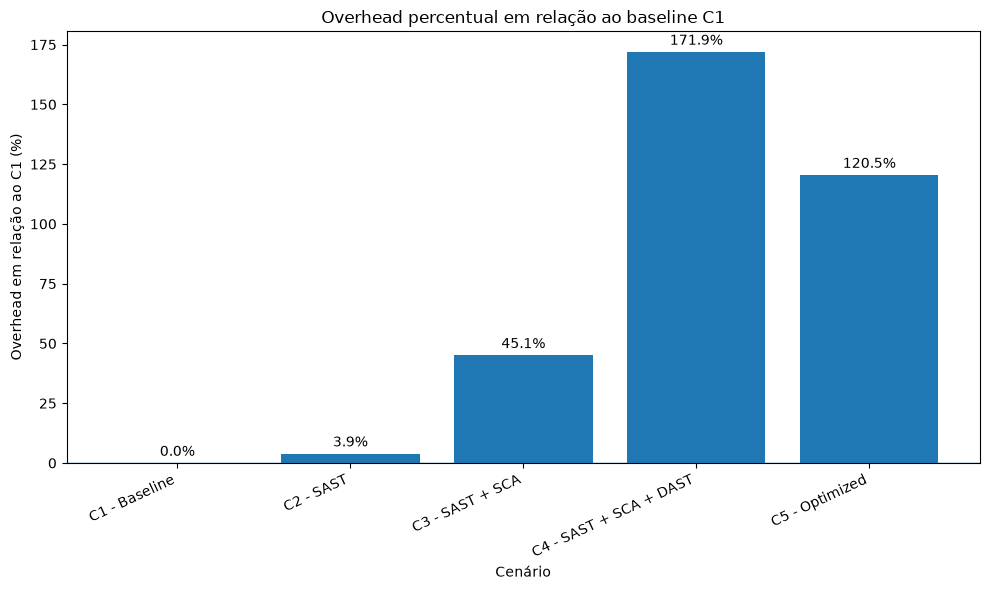

Gráfico salvo em: c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\charts\overhead_percentage_by_scenario.png
Arquivo existe: True


In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    baseline_overhead_rounded["scenario_label"],
    baseline_overhead_rounded["percentage_overhead_vs_c1"]
)

plt.title("Overhead percentual em relação ao baseline C1")
plt.xlabel("Cenário")
plt.ylabel("Overhead em relação ao C1 (%)")
plt.xticks(rotation=25, ha="right")

for index, value in enumerate(baseline_overhead_rounded["percentage_overhead_vs_c1"]):
    plt.text(
        index,
        value + 3,
        f"{value:.1f}%",
        ha="center"
    )

plt.axhline(0, linewidth=1)

plt.tight_layout()

overhead_chart_path = CHARTS_DIR / "overhead_percentage_by_scenario.png"
plt.savefig(overhead_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:", overhead_chart_path)
print("Arquivo existe:", overhead_chart_path.exists())

## 13. Comparação entre C4 e C5

Este gráfico compara o tempo médio total do workflow entre o cenário completo com SAST + SCA + DAST e o cenário otimizado.

O objetivo é verificar se as otimizações reduziram o lead time em relação ao pipeline DevSecOps completo.

In [17]:
c4_c5_comparison = scenario_stats_rounded[
    scenario_stats_rounded["scenario_key"].isin(["c4", "c5"])
].copy()

c4_c5_comparison

,scenario_order,scenario_key,scenario_label,executions,mean_seconds,median_seconds,min_seconds,max_seconds,std_seconds
3,4,c4,C4 - SAST + SCA + DAST,5,236.6,207.0,197,309,49.67
4,5,c5,C5 - Optimized,5,191.8,180.0,172,240,27.63


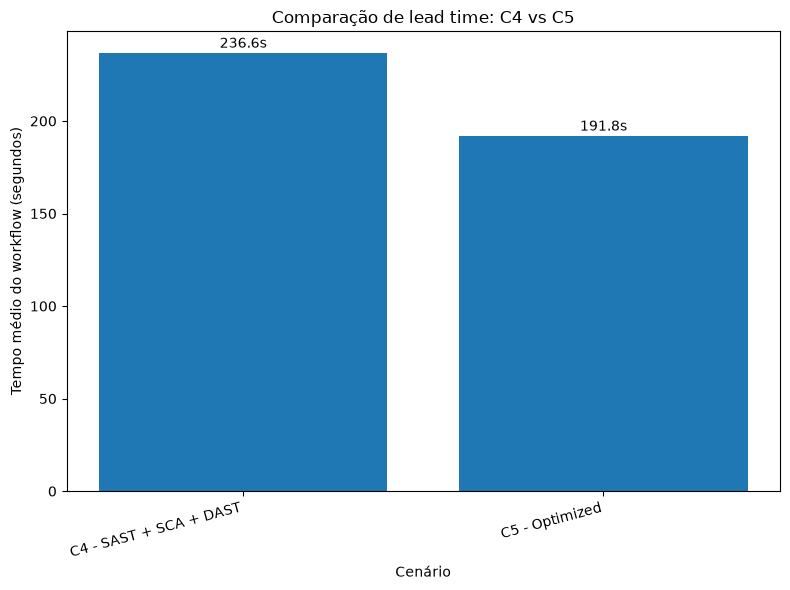

Gráfico salvo em: c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\charts\c4_vs_c5_optimization.png
Arquivo existe: True


In [18]:
plt.figure(figsize=(8, 6))

plt.bar(
    c4_c5_comparison["scenario_label"],
    c4_c5_comparison["mean_seconds"]
)

plt.title("Comparação de lead time: C4 vs C5")
plt.xlabel("Cenário")
plt.ylabel("Tempo médio do workflow (segundos)")
plt.xticks(rotation=15, ha="right")

for index, value in enumerate(c4_c5_comparison["mean_seconds"]):
    plt.text(
        index,
        value + 3,
        f"{value:.1f}s",
        ha="center"
    )

plt.tight_layout()

c4_c5_chart_path = CHARTS_DIR / "c4_vs_c5_optimization.png"
plt.savefig(c4_c5_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:", c4_c5_chart_path)
print("Arquivo existe:", c4_c5_chart_path.exists())

## 14. Exportação das tabelas consolidadas

Nesta seção, exportamos as principais tabelas da análise para arquivos CSV e Markdown.

Essas tabelas serão usadas na documentação dos resultados.

In [19]:
TABLES_DIR = PROJECT_ROOT / "analysis" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

scenario_stats_path = TABLES_DIR / "scenario_statistics.csv"
incremental_overhead_path = TABLES_DIR / "incremental_overhead.csv"
baseline_overhead_path = TABLES_DIR / "baseline_overhead.csv"
stage_stats_path = TABLES_DIR / "stage_statistics_by_scenario.csv"
stage_ranking_path = TABLES_DIR / "stage_ranking.csv"

scenario_stats_rounded.to_csv(scenario_stats_path, index=False)
incremental_overhead_df.to_csv(incremental_overhead_path, index=False)
baseline_overhead_rounded.to_csv(baseline_overhead_path, index=False)
stage_stats_rounded.to_csv(stage_stats_path, index=False)
stage_ranking_rounded.to_csv(stage_ranking_path, index=False)

print("Tabelas exportadas:")
print(scenario_stats_path)
print(incremental_overhead_path)
print(baseline_overhead_path)
print(stage_stats_path)
print(stage_ranking_path)

print("\nVerificação dos arquivos:")
for path in [
    scenario_stats_path,
    incremental_overhead_path,
    baseline_overhead_path,
    stage_stats_path,
    stage_ranking_path,
]:
    print(path.name, "->", path.exists())

Tabelas exportadas:
c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\tables\scenario_statistics.csv
c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\tables\incremental_overhead.csv
c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\tables\baseline_overhead.csv
c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\tables\stage_statistics_by_scenario.csv
c:\Users\arthur.soares\Desktop\TCC\tcc-devsecops-pipeline\analysis\tables\stage_ranking.csv

Verificação dos arquivos:
scenario_statistics.csv -> True
incremental_overhead.csv -> True
baseline_overhead.csv -> True
stage_statistics_by_scenario.csv -> True
stage_ranking.csv -> True
